In [1]:
'''
This notebook aim to provide a simplfied version of the source code of the paper 
"Reconstructing Training Data from Trained Neural Networks" (Haim et al., 2022)
'''

'\nThis notebook aim to provide a simplfied version of the source code of the paper \n"Reconstructing Training Data from Trained Neural Networks" (Haim et al., 2022)\n'

In [2]:
import os
import sys
sys.path.append('../')  # add the parent directory to the Python path

import torch
import torchvision
import numpy as np
import datetime
from models.mlp_reconstruction import MLP
from reconstruct_training_data.cifar10_vehicles_animals import get_dataloader

In [3]:
''' 
Parameters
'''
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# data creation
datadir = '../data/cifar10'
data_per_class_train=250 
data_reduce_mean=True

# training
data_per_class_train=250

# Reconstruction
reconstruction_data_amount_per_class=500 
reconstruction_epochs=50000 
reconstruction_evaluate_rate=1000 
reconstruction_init_scale=0.0008857493220221296 
reconstruction_lr=0.5549171806490206 
reconstruction_lambda_lr = 1e-4
reconstruction_lr_x = 1e-4
reconstruction_lr_l = 1e-4
reconstruction_min_lambda=0.4983026413803425 
reconstruction_model_relu_alpha=19.14455192462549 
reconstruction_stop_threshold = 5000

# model
input_dim = 32 * 32 * 3     # CIFAR-10 images have 32x32 pixels and 3 color channels (RGB), and MLP takes flattened images as input
num_classes = 2     # binary classification (vehicles vs animals)
output_dim = 1      # for binary classification -> probability of being in one of the two classes
model_hidden_list=[1000,1000] 
model_init_list=[0.001,0.001]

reconstruction_data_amount = reconstruction_data_amount_per_class * num_classes
data_amount = data_per_class_train * num_classes

# Path to load the pre-trained weights provided by the authors of the paper
attacked_model_paths = '../results/Attacked_Models/weights-cifar10_vehicles_animals_from_authors.pth'
output_dir = '../results/Reconstruction_Results/'
os.makedirs(output_dir, exist_ok=True)
# absolute path - sanity check
print(os.path.abspath(attacked_model_paths))

Using device: cpu
/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/cifar/results/Attacked_Models/weights-cifar10_vehicles_animals_from_authors.pth


/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/cifar/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
'''
Support utils function
'''
@torch.no_grad()
def calc_model_parameters(model):
    l = [torch.tensor(p.shape).prod() for p in model.parameters()]
    print('Parameters per Layer:', l)
    print('Total Parameters:', torch.tensor(l).sum().item())

def load_weights(model, fpath, device='cuda'):
    print("loading weights '{}'".format(fpath))
    weights = torch.load(fpath, map_location=device)

    weights['state_dict'] = {k.replace('convnet','layers'): v for k, v in weights['state_dict'].items()}

    model.load_state_dict(weights['state_dict'])
    return model

In [5]:
'''Data processing'''
train_loader = get_dataloader(datadir, data_amount, input_dim, num_classes, output_dim, device)

TRAINSET BALANCED


/mnt/d/DUY/LUH/Hiwi_TNT/Tasks/cifar/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


BALANCING DATASET...
X: torch.Size([500, 3, 32, 32])
y: torch.Size([500])
BALANCE: 0: 250, 1: 250


In [6]:
''' 
Load pre-trained model
'''
# Create model architecture
attacked_model = MLP(input_dim, model_hidden_list, output_dim, reconstruction_model_relu_alpha)
attacked_model = attacked_model.to(device)
calc_model_parameters(attacked_model)
attacked_model.eval()
attacked_model = load_weights(attacked_model, attacked_model_paths, device=device)
print('ATTACKED MODEL:')
print(attacked_model)

Parameters per Layer: [tensor(3072000), tensor(1000), tensor(1000000), tensor(1000)]
Total Parameters: 4074000
loading weights '../results/Attacked_Models/weights-cifar10_vehicles_animals_from_authors.pth'
ATTACKED MODEL:
MLP(
  (activation): ModifiedRelu()
  (layers): ModuleList(
    (0): Linear(in_features=3072, out_features=1000, bias=True)
    (1): Linear(in_features=1000, out_features=1000, bias=False)
    (2): Linear(in_features=1000, out_features=1, bias=False)
  )
)


In [7]:
'''
Create labels (n-labels to -1 and n-labels to 1) -> to ensure there is solution to Eq.8 in the paper
'''
y = torch.zeros(reconstruction_data_amount).type(torch.get_default_dtype()).to(device)
y[:y.shape[0] // 2] = -1
y[y.shape[0] // 2:] = 1
y = y.long()
print('y type,shape:', y.type(), y.shape)

torch.save(y, os.path.join(output_dir, 'y.pth'))

y type,shape: torch.LongTensor torch.Size([1000])


In [8]:
'''
Initialize random trainable variables (x and lamda)
'''
x0, y0 = next(iter(train_loader))
print('X:', x0.shape, x0.device)
print('y:', y0.shape, y0.device)
print('model device:', attacked_model.layers[0].weight.device)

ds_mean = x0.mean(dim=0, keepdims=True)
x0 = x0 - ds_mean

n, c, h, w = x0.shape
x = torch.randn(reconstruction_data_amount, c, h, w).to(device) * reconstruction_init_scale
x.requires_grad_(True)
l = torch.rand(reconstruction_data_amount, 1).to(device)
l.requires_grad_(True)
opt_x = torch.optim.SGD([x], lr=reconstruction_lr, momentum=0.9)
opt_l = torch.optim.SGD([l], lr=reconstruction_lambda_lr, momentum=0.9)

print('l type,shape:', l.type(), l.shape)

X: torch.Size([500, 3, 32, 32]) cpu
y: torch.Size([500]) cpu
model device: cpu
l type,shape: torch.FloatTensor torch.Size([1000, 1])


In [9]:
'''
Reconstruction loss components - Corresponding to Eq.6, 7, 8 in the paper
'''

# Stationary loss (KKT loss)
def get_kkt_loss(values, l, y, model, extraction_data_amount):
    l = l.squeeze()
    # all three shape should be (n)
    assert values.dim() == 1
    assert l.dim() == 1
    assert y.dim() == 1
    assert values.shape == l.shape == y.shape

    output = values * l * y
    grad = torch.autograd.grad(
        outputs=output,
        inputs=model.parameters(),
        grad_outputs=torch.ones_like(output, requires_grad=False, device=output.device).div(extraction_data_amount),
        create_graph=True,
        retain_graph=True,
    )
    kkt_loss = 0

    for i, (p, grad) in enumerate(zip(model.parameters(), grad)):
        assert p.shape == grad.shape
        l = (p.detach().data - grad).pow(2).sum()
        kkt_loss += l

    return kkt_loss


def get_verify_loss(x, l, reconstruction_min_lambda):
    loss_verify = 0
    loss_verify += 1 * (x - 1).relu().pow(2).sum()
    loss_verify += 1 * (-1 - x).relu().pow(2).sum()
    loss_verify += 5 * (-l + reconstruction_min_lambda).relu().pow(2).sum()

    return loss_verify


In [10]:
'''
Evaluation function
'''

def normalize_batch(x, ret_all=False):
    """ Normalize each element in batch x --> (x-mean)/std"""
    n, c, h, w = x.shape
    means = x.reshape(n * c, h * w).mean(dim=1).reshape(n, c, 1, 1)
    stds = x.reshape(n * c, h * w).std(dim=1).reshape(n, c, 1, 1)
    if ret_all:
        return x.sub(means).div(stds), means, stds
    else:
        return x.sub(means).div(stds)


def l2_dist(x, y, div_dim=False):
    """ L2 distance between x and y """
    x = x.reshape(x.shape[0], -1)
    y = y.reshape(y.shape[0], -1)

    xx = x.pow(2).sum(1).view(-1, 1)
    yy = y.pow(2).sum(1).view(1, -1)
    xy = torch.einsum('id,jd->ij', x, y)
    dists = xx + yy - 2 * xy

    if div_dim:
        N, D = x.shape
        dists /= D

    return dists

def ncc_dist(x, y, div_dim=False):
    """ Normalized Cross-Correlation distacne between x and y """
    return l2_dist(normalize_batch(x), normalize_batch(y), div_dim)

def viz_nns(x, y, max_per_nn=None):
    """
    return a batch, for each image in x, its nn in y
    sorted according to closest nn
    metric: NCC
    max_per_nn: filter duplicates (leave only max_per_nn elements of y-elements)
    """

    dists = ncc_dist(x, y)

    v, nn_idx = dists.min(dim=1)

    keep = None
    if max_per_nn is not None:
        nn_idx_vals_i = torch.stack([nn_idx, v, torch.arange(v.shape[0], device=v.device)])
        nn_idx_vals_i = [(int(a), b, int(c)) for a, b, c in nn_idx_vals_i.t().tolist()]  # bring indexes back to int
        sorted_stuff = sorted(nn_idx_vals_i)

        # filter duplicates (leave only max_per_nn from each image from y)
        counter = 0
        cur_idx = sorted_stuff[0][0]
        keep = []
        for e in sorted_stuff:
            if e[0] != cur_idx:
                cur_idx = e[0]
                counter = 0
            if counter < max_per_nn:
                keep.append(e)
                counter += 1
        # sort by best value first
        keep = sorted(keep, key=lambda q: q[1])
        # keep is now: (nn idx in y, value, idx of x)
        xx = x[torch.tensor([e[2] for e in keep])]
        yy = y[torch.tensor([e[0] for e in keep])]
        v = torch.tensor([e[1] for e in keep])
    else:
        _, sidxs = v.sort()
        xx = x[sidxs]
        yy = y[nn_idx[sidxs]]

    return v


def evaluate_reconstruction(x, x0):
    x = x.clone().data

    xx = x.data.clone()
    yy = x0.clone()

    v = viz_nns(xx, yy, max_per_nn=1)
    reconstruction_score = v[:10].mean().item()

    return reconstruction_score

In [11]:
# '''
# Reconstruction loop
# '''
# for epoch in range(reconstruction_epochs):
#     values = attacked_model(x).squeeze()
#     kkt_loss, loss_verify = torch.tensor(0), torch.tensor(0)
#     kkt_loss = get_kkt_loss(values, l, y, attacked_model, reconstruction_data_amount)
#     loss_verify = get_verify_loss(x, l, reconstruction_min_lambda)
#     loss = kkt_loss + loss_verify
#     if np.isnan(kkt_loss.item()):
#         raise ValueError('Optimizer diverged during extraction')
#     opt_x.zero_grad()
#     opt_l.zero_grad()
#     loss.backward()
#     opt_x.step()
#     opt_l.step()

#     if epoch % reconstruction_evaluate_rate == 0:
#         reconstruction_score = evaluate_reconstruction(x, x0)
#         print(f'Epoch: {epoch}, Reconstruction Score: {reconstruction_score}')
#         torch.save(x, os.path.join(output_dir, 'x', f'epoch_{epoch}_x_{reconstruction_score}.pth'))
#         torch.save(l, os.path.join(output_dir, 'l', f'epoch_{epoch}_l_{reconstruction_score}.pth'))
#         if epoch >= reconstruction_stop_threshold and reconstruction_score > 3300:
#             print('Reconstruction Score is too high. Epoch:', epoch, 'Score:', reconstruction_score)
#             break

## Post processing - showing top 45 best reconstruction pairs - as detailed in Appendix B.3

In [12]:
'''
Get the original training data
'''
X_trained = next(iter(train_loader))[0]
ds_mean = X_trained.mean(dim=0, keepdims=True)
X_trained = X_trained - ds_mean

In [13]:
''' 
Read reconstructed data 
'''
import os

output_dir = '../results/Reconstruction_Results/'

x_paths = [
    os.path.join(output_dir, 'x', 'epoch_27000_x_1362.1412353515625.pth'),
    os.path.join(output_dir, 'x', 'epoch_28000_x_1362.0113525390625.pth')
]
# X = torch.load(x_paths[0])
# X = torch.load(x_paths[1])
X = torch.cat([torch.load(x_paths[0]), torch.load(x_paths[1])])

In [16]:
''' 
Get and show top reconstructed data 
'''
import kornia.metrics as metrics
import itertools
from tqdm import tqdm
import matplotlib.pyplot as plt

# =====================================================================
# Helper functions for the obtaining and visualizing reconstructed data
# =====================================================================

flatten = lambda x: list(itertools.chain.from_iterable(x))

def get_ssim_pairs_kornia(x, y):
    return metrics.ssim(x, y, window_size=3).reshape(x.shape[0], -1).mean(dim=1)

def transform_vmin_vmax_batch(x, min_max=None):
    """ Transform each image in x: [min, max] --> [0, 1]"""
    if min_max is None:
        vmin = x.data.reshape(x.shape[0], -1).min(dim=1)[0][:, None, None, None]
        vmax = x.data.reshape(x.shape[0], -1).max(dim=1)[0][:, None, None, None]
    else:
        vmin, vmax = min_max
    return (x - vmin).div(vmax - vmin)

@torch.no_grad()
def find_nearest_neighbour(X, x0, search='ncc', vote='min', use_bb=True, nn_threshold=None, ret_idxs=False):
    xxx = X.clone()
    yyy = x0.clone()


    if search == 'ncc2':
        x2search = torch.nn.functional.interpolate(xxx, scale_factor=1 / 2, mode='bicubic', align_corners=False)
        y2search = torch.nn.functional.interpolate(yyy, scale_factor=1 / 2, mode='bicubic', align_corners=False)
        D = ncc_dist(y2search, x2search, div_dim=True)


    dists, idxs = D.sort(dim=1, descending=False)

    # yy = yyy
    if vote == 'min' or vote is None:
        xx = xxx[idxs[:, 0]]
    else:
        raise

    return xx

@torch.no_grad()
def scale(xx, x0, ds_mean, xx_add_ds_mean=True):
    xx = xx.clone()
    x0 = x0.clone()
    ds_mean = ds_mean.clone()
    # Scale to images
    yy = x0 + ds_mean
    if xx_add_ds_mean:
        xx = transform_vmin_vmax_batch(xx + ds_mean)
    else:
        xx = transform_vmin_vmax_batch(xx)

    return xx, yy


@torch.no_grad()
def sort_by_metric(xx, yy, sort='ssim'):
    xx = xx.clone()
    yy = yy.clone()

    # Score
    psnr = lambda a, b: 20 * torch.log10(1.0 / (a - b).pow(2).reshape(a.shape[0], -1).mean(dim=1).sqrt())

    # Sort
    if sort == 'ssim':
        dists = get_ssim_pairs_kornia(xx, yy)
        dssim = (1 - dists) / 2
        _, sort_idxs = dists.sort(descending=True)
    else:
        raise

    xx = xx[sort_idxs]
    yy = yy[sort_idxs]
    return xx, yy, dists, sort_idxs


@torch.no_grad()
def plot_table(xx, yy, fig_elms_in_line, fig_lines_per_page, fig_type='side_by_side',
               figpath=None, show=False, dpi=100, color_by_labels=None):
    # PRINT TABLES
    xx = xx.clone()
    yy = yy.clone()

    RED = torch.tensor([1, 0, 0])[None, :, None, None]
    BLUE = torch.tensor([0, 1, 0])[None, :, None, None]
    def add_colored_margin(x, labels, p=1):
        n, c, h, w = x.shape
        bg = torch.zeros(n, c, h + 2 * p, w + 2 * p)
        bg[labels == 0] += RED
        bg[labels == 1] += BLUE
        bg[:, :, p:-p, p:-p] = x
        return bg

    if color_by_labels is not None:
        yy = add_colored_margin(yy, color_by_labels, p=2)
        xx = add_colored_margin(xx, color_by_labels, p=2)

    if fig_type == 'side_by_side':
        qq = torch.stack(flatten(list(zip(xx, yy))))
    elif fig_type == 'one_above_another':
        q_zip = flatten(list(zip(torch.split(xx, fig_elms_in_line), torch.split(yy, fig_elms_in_line))))
        if len(q_zip) > 2:
            q_zip = q_zip[:-2]
            print('CUT the end of the zipped bla because it might have different shape before torch.cat')
        qq = torch.cat(q_zip)
    else:
        raise

    lines_num = qq.shape[0] // fig_elms_in_line
    print(qq.shape, lines_num)
    for page_num, line_num in enumerate(tqdm(range(0, lines_num, fig_lines_per_page))):
        s = line_num * fig_elms_in_line
        e = (line_num + fig_lines_per_page) * fig_elms_in_line
        print(page_num, s, e)
        grid = torchvision.utils.make_grid(qq[s:e], normalize=False, nrow=fig_elms_in_line, pad_value=1)
        if figpath is not None:
            plt.imsave(figpath, grid.permute(1, 2, 0).cpu().numpy(), dpi=dpi)
            print('Saved fig at:', figpath)
        if show:
            plt.figure(figsize=(80 * 2, 10 * 2))
            plt.axis('off')
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.show()
        plt.close('all')
        break
    print('DONE!')


CUT the end of the zipped bla because it might have different shape before torch.cat
torch.Size([990, 3, 32, 32]) 66


  0%|          | 0/17 [00:00<?, ?it/s]

0 0 60


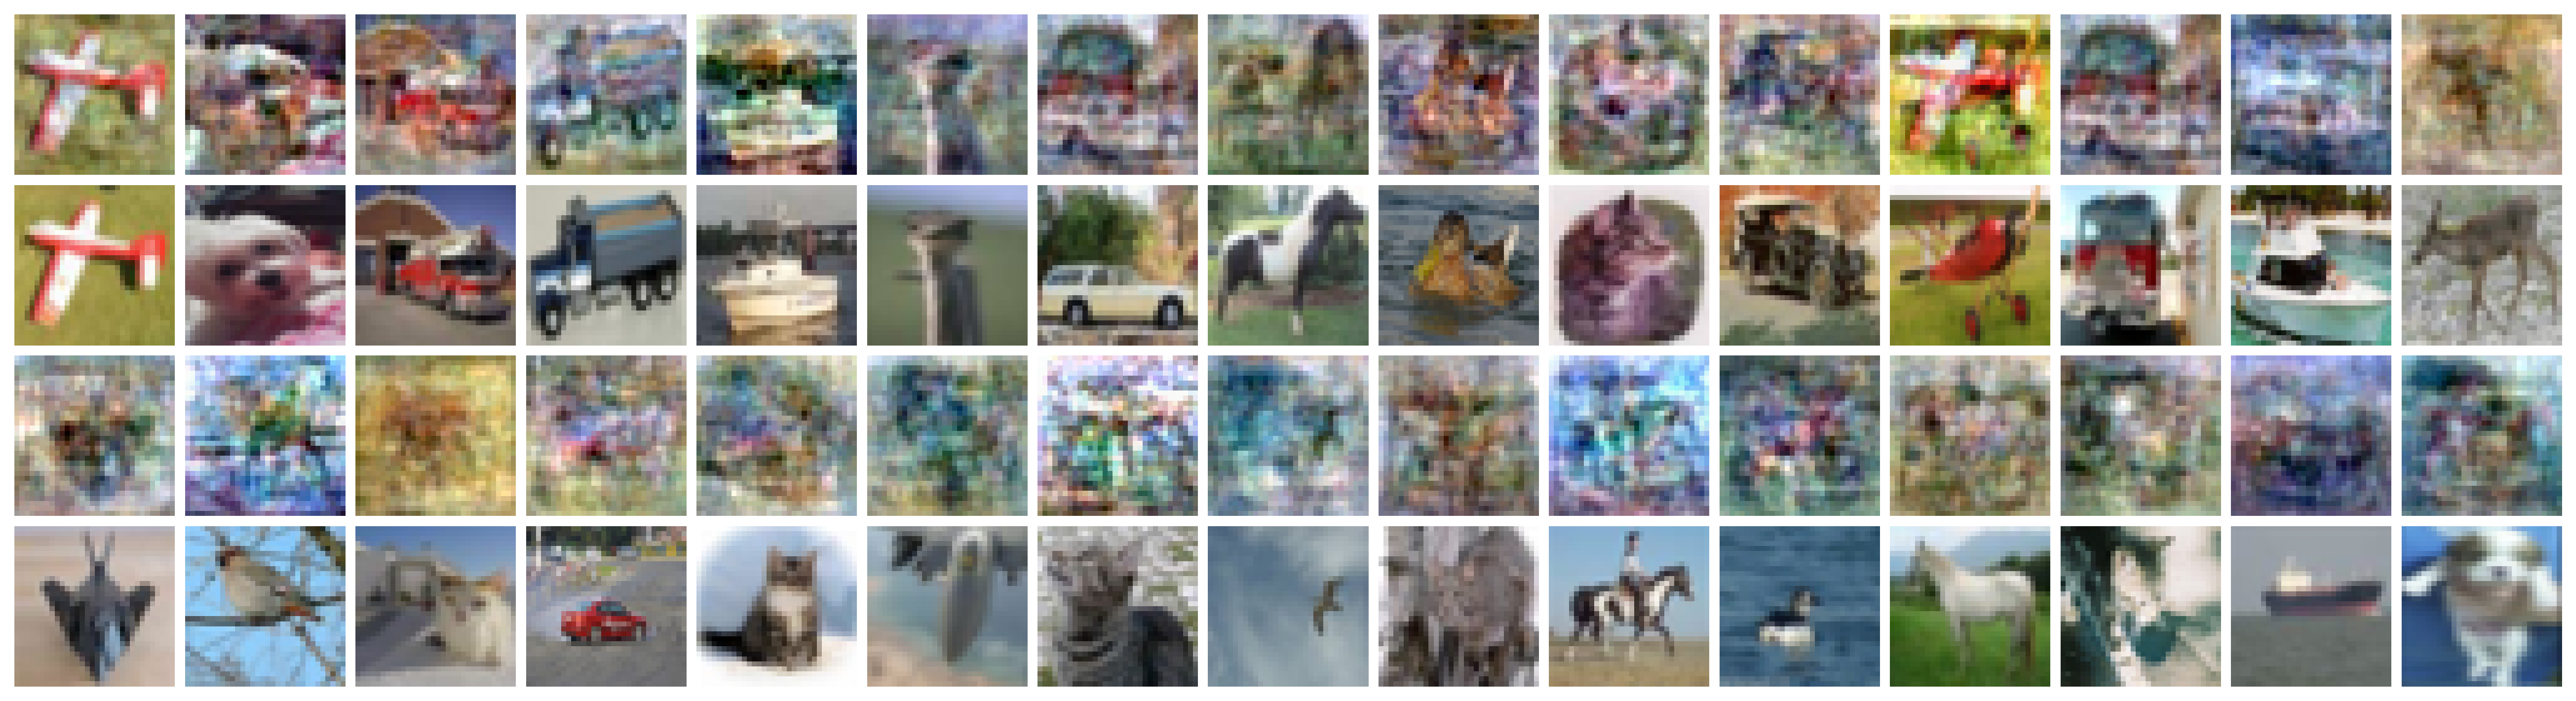

  0%|          | 0/17 [00:01<?, ?it/s]

DONE!


In [17]:
# =====================================================================
# Obtain and visualize reconstructed data
# =====================================================================

# Find Nearest Neighbour
xx1 = find_nearest_neighbour(X, X_trained, search='ncc2', vote='min', use_bb=False, nn_threshold=1000)
# Scale to Images
xx_scaled, yy_scaled = scale(xx1, X_trained, ds_mean)
# # Sort
xx, yy, ssims, sort_idxs = sort_by_metric(xx_scaled, yy_scaled, sort='ssim')

# Plot
color_by_labels = None
figpath=None
plot_table(xx, yy, fig_elms_in_line=15, fig_lines_per_page=4, fig_type='one_above_another', color_by_labels=color_by_labels, figpath=figpath, show=True, dpi=100)